In [ ]:
import sklearn

In [ ]:
sklearn.__version__

'1.3.0'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score


PREPROCESSING

In [ ]:
data=pd.read_csv(r"C:\Users\dell\Documents\Machine learning\Cusat\Datasets\Stars.csv")

In [ ]:
data.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


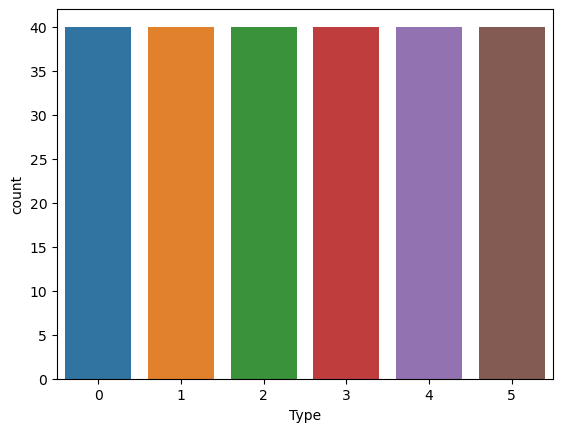

In [ ]:
x=data['Type']
ax=sns.countplot(x=x,data=data)

In [ ]:
data.isnull().sum()

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
Type              0
dtype: int64

In [ ]:
le=LabelEncoder()
data['Type']=le.fit_transform(data['Type'])
data.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
data[["Temperature"]]=scaler.fit_transform(data[["Temperature"]])
data[["L"]]=scaler.fit_transform(data[["L"]])
data[["R"]]=scaler.fit_transform(data[["L"]])
data[["A_M"]]=scaler.fit_transform(data[["A_M"]])

In [ ]:
data

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,0.029663,2.731275e-09,2.731275e-09,0.876798,Red,M,0
1,0.028980,4.944550e-10,4.944550e-10,0.891807,Red,M,0
2,0.017367,2.590003e-10,2.590003e-10,0.957473,Red,M,0
3,0.022622,1.412729e-10,1.412729e-10,0.893371,Red,M,0
4,0.000000,6.828189e-11,6.828189e-11,1.000000,Red,M,0
...,...,...,...,...,...,...,...
235,0.972150,4.412776e-01,4.412776e-01,0.062226,Blue,O,5
236,0.759307,9.818959e-01,9.818959e-01,0.040338,Blue,O,5
237,0.181025,6.327765e-01,6.327765e-01,0.037211,White,A,5
238,0.191692,4.767253e-01,4.767253e-01,0.021576,White,A,5


In [ ]:
obj=["Color","Spectral_Class"]
for i in obj:
    data[i]=le.fit_transform(data[i])

In [ ]:
data

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,0.029663,2.731275e-09,2.731275e-09,0.876798,8,5,0
1,0.028980,4.944550e-10,4.944550e-10,0.891807,8,5,0
2,0.017367,2.590003e-10,2.590003e-10,0.957473,8,5,0
3,0.022622,1.412729e-10,1.412729e-10,0.893371,8,5,0
4,0.000000,6.828189e-11,6.828189e-11,1.000000,8,5,0
...,...,...,...,...,...,...,...
235,0.972150,4.412776e-01,4.412776e-01,0.062226,0,6,5
236,0.759307,9.818959e-01,9.818959e-01,0.040338,0,6,5
237,0.181025,6.327765e-01,6.327765e-01,0.037211,9,0,5
238,0.191692,4.767253e-01,4.767253e-01,0.021576,9,0,5


In [ ]:
y=data['Type'].values.reshape(-1,1)

In [ ]:
x=data.drop(['Type'],axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

Applying algorithms

1.Naive Bayes

In [ ]:
nb=GaussianNB()
nb.fit(x_train,y_train)
nbpred=nb.predict(x_test)

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print("Accuracy: %.2f" %accuracy_score(y_test,nbpred))

Accuracy: 0.35


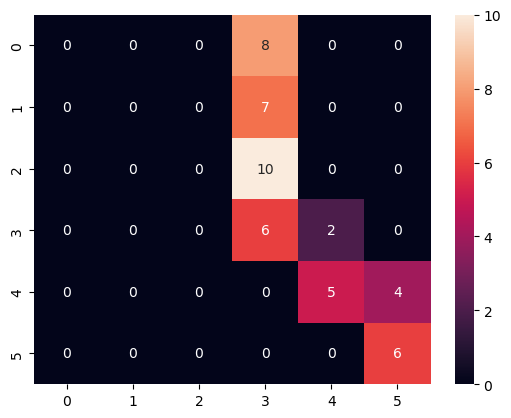

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        10
           3       0.19      0.75      0.31         8
           4       0.71      0.56      0.63         9
           5       0.60      1.00      0.75         6

    accuracy                           0.35        48
   macro avg       0.25      0.38      0.28        48
weighted avg       0.24      0.35      0.26        48



C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
cf_matrix_nb=confusion_matrix(y_test,nbpred).astype(int)
sns.heatmap(cf_matrix_nb,fmt="d",annot=True)
plt.show()
print(classification_report(y_test,nbpred))

2.KNN

In [ ]:
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train,y_train)
knn_predicted=knn.predict(x_test)

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [ ]:
print("Accuracy: ",accuracy_score(y_test,knn_predicted))

Accuracy:  0.8958333333333334


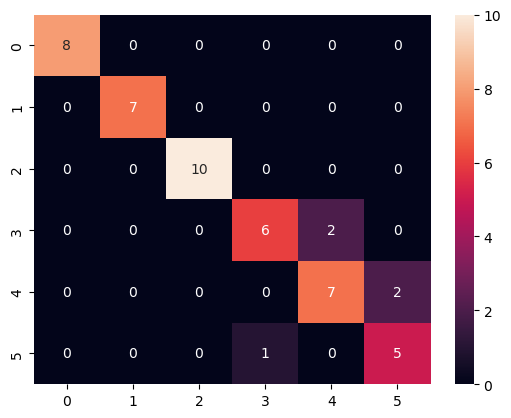

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        10
           3       0.86      0.75      0.80         8
           4       0.78      0.78      0.78         9
           5       0.71      0.83      0.77         6

    accuracy                           0.90        48
   macro avg       0.89      0.89      0.89        48
weighted avg       0.90      0.90      0.90        48



In [ ]:
cf_matrix_nb=confusion_matrix(y_test,knn_predicted).astype(int)
sns.heatmap(cf_matrix_nb,fmt="d",annot=True)
plt.show()
print(classification_report(y_test,knn_predicted))

3.Decision Tree

In [ ]:
dt=DecisionTreeClassifier(criterion='entropy',random_state=0,max_depth=6)
dt.fit(x_train,y_train)
dt_predicted=dt.predict(x_test)

In [ ]:
print("Accuracy: %.2f" %accuracy_score(y_test,dt_predicted))

Accuracy: 0.35


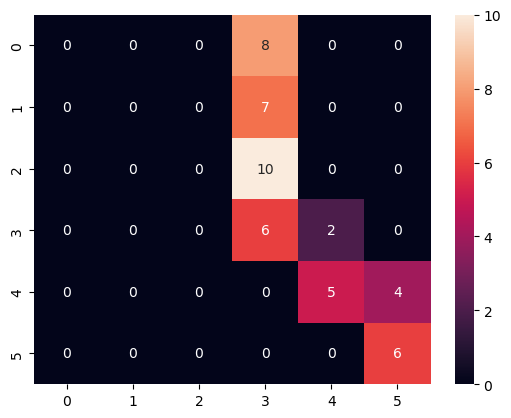

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        10
           3       0.19      0.75      0.31         8
           4       0.71      0.56      0.63         9
           5       0.60      1.00      0.75         6

    accuracy                           0.35        48
   macro avg       0.25      0.38      0.28        48
weighted avg       0.24      0.35      0.26        48



C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
cf_matrix_nb=confusion_matrix(y_test,dt_predicted).astype(int)
sns.heatmap(cf_matrix_nb,fmt="d",annot=True)
plt.show()
print(classification_report(y_test,dt_predicted))

4.Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_reg=LogisticRegression()
logistic_reg.fit(x_train,y_train)
y_pred=logistic_reg.predict(x_test)

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print("Accuracy: %.2f" %accuracy_score(y_test,y_pred))

Accuracy: 0.96


In [ ]:
tp,fp,fn,tn=confusion_matrix(y_test,y_pred).ravel()
cf=confusion_matrix(y_test,y_pred)
cf

NameError: name 'confusion_matrix' is not defined

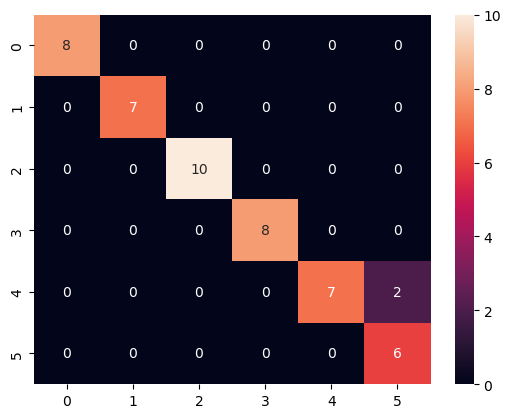

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00         8
           4       1.00      0.78      0.88         9
           5       0.75      1.00      0.86         6

    accuracy                           0.96        48
   macro avg       0.96      0.96      0.96        48
weighted avg       0.97      0.96      0.96        48



In [ ]:
cf_matrix=confusion_matrix(y_test,y_pred).astype(int)
sns.heatmap(cf_matrix,fmt="d",annot=True)
plt.show()
print(classification_report(y_test,y_pred))

The following algorithms were applied and model had the following accuracy
    1.Naive Bayes: 0.35
    2.KNN: 0.90
    3.Decision Tree: 0.35
    4.Logistic Regression: 0.96
    
    Hence the best is Logistic Regression model for this dataset